# Resources

This notebook utilizes the following resources:

*   **Dataset**: Bank Account Fraud Detection Dataset (from KaggleHub: `sgpjesus/bank-account-fraud-dataset-neurips-2022`)
*   **Libraries**:
    *   `pandas` for data manipulation and analysis.
    *   `scikit-learn` for data splitting, baseline model (Logistic Regression), and evaluation metrics.
    *   `LightGBM` for gradient boosting machine learning.
    *   `Optuna` for hyperparameter optimization of the LightGBM model.
    *   `matplotlib` and `seaborn` for data visualization.
    *   `kagglehub` for dataset downloading.
    *   `os` and `shutil` for file system operations (e.g., copying to Google Drive).
*   **Platform**: Google Colaboratory for execution and environment setup.

In [ ]:
import os
import kagglehub
import pandas as pd

# 1. Download the full suite via kagglehub
path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
print("Dataset downloaded to:", path)

# 2. List the available variant files in the directory
files = os.listdir(path)
print("\nAvailable files in suite:")
for f in files:
    if f.endswith('.csv'):
        print(f" - {f}")

# 3. Load the Base dataset to start modeling
# (Change the filename to test out the drift variants like 'Variant_1.csv', etc.)
base_df_path = os.path.join(path, "Base.csv")
df = pd.read_csv(base_df_path)

print(f"\nSuccessfully loaded Base dataset: {df.shape[0]} rows, {df.shape[1]} columns.")

100%|██████████| 532M/532M [00:26<00:00, 21.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/versions/2

Available files in suite:
 - Base.csv
 - Variant I.csv
 - Variant IV.csv
 - Variant II.csv
 - Variant III.csv
 - Variant V.csv

Successfully loaded Base dataset: 1000000 rows, 32 columns.


In [ ]:
# Get a summary of statistical information for each numerical column in the DataFrame
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [ ]:
print("\nDataFrame Information (data types, non-null counts):")
display(df.info())


DataFrame Information (data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-nul

None

In [ ]:
# Get a summary of statistical information for each non-numerical column in the DataFrame
df.describe(include=["object", "bool"]).transpose()

,count,unique,top,freq
payment_type,1000000,5,AB,370554
employment_status,1000000,7,CA,730252
housing_status,1000000,7,BC,372143
source,1000000,2,INTERNET,992952
device_os,1000000,5,other,342728


In [ ]:
# Get the number of unique values in each column of the DataFrame
df.nunique()

,0
fraud_bool,2
income,9
name_email_similarity,998861
prev_address_months_count,374
current_address_months_count,423
customer_age,9
days_since_request,989330
intended_balcon_amount,994971
payment_type,5
zip_count_4w,6306


In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns: {list(categorical_cols)}")

# Perform one-hot encoding on categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding:")
display(df_encoded.head())

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

DataFrame after one-hot encoding:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BC,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_TELEAPP,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,1059,13096.035018,...,True,False,False,False,False,False,False,False,False,False
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,1658,9223.283431,...,True,False,False,False,False,False,False,True,False,False
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,1095,4471.472149,...,True,False,False,False,False,False,False,False,True,False
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,3483,14431.993621,...,True,False,False,False,False,False,False,False,False,False
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,2339,7601.511579,...,True,False,False,False,False,False,False,True,False,False


### Handle Missing Values

From the `df.info()` output, we observed that there are no missing values across any columns, as all `Non-Null Count` values match the total number of entries (1,000,000). Therefore, no specific imputation or removal of missing data is required for this dataset.

### Handling Encoded Missing Values

As highlighted, some columns use `-1` as a placeholder for missing values, which `df.info()` might not detect as `NaN`. We will identify these columns and replace `-1` with `NaN`, then impute these missing values with the median to maintain data integrity and prevent issues during modeling.

In [ ]:
import numpy as np

# Columns identified from df.describe() as having -1 as a placeholder for missing values
missing_value_cols = ['prev_address_months_count', 'current_address_months_count', 'bank_months_count']

# Replace -1 with NaN in the identified columns
for col in missing_value_cols:
    df_encoded[col] = df_encoded[col].replace(-1, np.nan)

print("Count of NaN values after replacing -1:")
display(df_encoded[missing_value_cols].isnull().sum())

Count of NaN values after replacing -1:


,0
prev_address_months_count,712920
current_address_months_count,4254
bank_months_count,253635


In [ ]:
# Impute NaN values with the median for each column
for col in missing_value_cols:
    median_value = df_encoded[col].median()
    df_encoded[col] = df_encoded[col].fillna(median_value)

print(f"DataFrame head after imputing NaN values with the median:\n")
display(df_encoded.head())

print(f"\nSummary statistics for imputed columns after handling -1:\n")
display(df_encoded[missing_value_cols].describe().transpose())

DataFrame head after imputing NaN values with the median:



,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BC,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_TELEAPP,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.3,0.986506,34.0,25.0,40,0.006735,102.453711,1059,13096.035018,...,True,False,False,False,False,False,False,False,False,False
1,0,0.8,0.617426,34.0,89.0,20,0.010095,-0.849551,1658,9223.283431,...,True,False,False,False,False,False,False,True,False,False
2,0,0.8,0.996707,9.0,14.0,40,0.012316,-1.490386,1095,4471.472149,...,True,False,False,False,False,False,False,False,True,False
3,0,0.6,0.475100,11.0,14.0,30,0.006991,-1.863101,3483,14431.993621,...,True,False,False,False,False,False,False,False,False,False
4,0,0.9,0.842307,34.0,29.0,40,5.742626,47.152498,2339,7601.511579,...,True,False,False,False,False,False,False,True,False,False



Summary statistics for imputed columns after handling -1:



,count,mean,std,min,25%,50%,75%,max
prev_address_months_count,1000000.0,41.670768,36.146230,5.0,34.0,34.0,34.0,383.0
current_address_months_count,1000000.0,86.817583,88.248728,0.0,20.0,53.0,130.0,428.0
bank_months_count,1000000.0,14.897463,9.959364,1.0,5.0,15.0,25.0,32.0


### Outlier Detection and Handling

Outliers can significantly impact model performance. While this notebook does not explicitly remove them, here are common strategies to identify and handle outliers, which can be applied depending on the context and domain knowledge:

*   **Identification Methods**:
    *   **Z-score**: For normally distributed data, values beyond 2 or 3 standard deviations from the mean can be considered outliers.
    *   **IQR (Interquartile Range)**: For skewed data, values falling outside `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` are often considered outliers. Box plots are excellent for visualizing these.
    *   **Isolation Forest or One-Class SVM**: Machine learning algorithms specifically designed for anomaly detection.

*   **Handling Strategies**:
    *   **Removal**: If outliers are due to data entry errors or are rare and distinct from the rest of the data, they can be removed.
    *   **Transformation**: Applying transformations (e.g., log, square root) can reduce the impact of outliers by compressing the range of values.
    *   **Capping/Winsorization**: Limiting extreme values to a certain percentile (e.g., replacing values above the 99th percentile with the 99th percentile value).
    *   **Imputation**: If outliers are believed to be valid but extreme, they can sometimes be treated as missing values and imputed using robust methods like median imputation.

For this dataset, given its large size and the nature of fraud detection (where extreme values might be indicative of fraud), a careful analysis would be needed before deciding on an outlier handling strategy. It's often beneficial to train models with and without outlier treatment to compare their performance.

In [ ]:
from scipy.stats import zscore

# Calculate Z-scores for the 'income' column
df_encoded['income_zscore'] = zscore(df_encoded['income'])

# Identify outliers based on a Z-score threshold (e.g., |Z| > 3)
outliers_income = df_encoded[abs(df_encoded['income_zscore']) > 3]

print(f"Number of outliers in 'income' column (absolute Z-score > 3): {len(outliers_income)}")
if not outliers_income.empty:
    print("\nOutliers in 'income' column (first 5 rows if many):")
    display(outliers_income.head())
else:
    print("No significant outliers found in 'income' column with Z-score > 3.")

Number of outliers in 'income' column (absolute Z-score > 3): 0
No significant outliers found in 'income' column with Z-score > 3.


### Outlier Detection for All Numerical Variables

Continuing with outlier detection, we will now apply the Z-score method to all numerical columns in the `df_encoded` DataFrame. This will help us identify potential outliers across the entire dataset, which might warrant further investigation or specific handling depending on the context of the analysis.

In [ ]:
numerical_cols = df_encoded.select_dtypes(include=np.number).columns.tolist()

# Remove the target variable and previously created z-score column
if 'fraud_bool' in numerical_cols:
    numerical_cols.remove('fraud_bool')
if 'income_zscore' in numerical_cols:
    numerical_cols.remove('income_zscore')

print("Performing outlier detection for the following numerical columns:")
print(numerical_cols)

outlier_summary = {}

for col in numerical_cols:
    if col in df_encoded.columns:
        # Calculate Z-scores for the current column
        df_encoded[f'{col}_zscore'] = zscore(df_encoded[col])

        # Identify outliers based on a Z-score threshold (e.g., |Z| > 3)
        outliers = df_encoded[abs(df_encoded[f'{col}_zscore']) > 3]

        num_outliers = len(outliers)
        outlier_summary[col] = num_outliers

        print(f"\nColumn '{col}': {num_outliers} outliers (absolute Z-score > 3)")
        if num_outliers > 0:
            print("Outliers (first 5 rows if many):")
            display(outliers[[col, 'fraud_bool', f'{col}_zscore']].head())

print("\n--- Outlier Detection Summary ---")
for col, count in outlier_summary.items():
    print(f"'{col}': {count} outliers")

Performing outlier detection for the following numerical columns:
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']

Column 'income': 0 outliers (absolute Z-score > 3)

Column 'name_email_similarity': 0 outliers (absolute Z-score > 3)

Column 'prev_address_months_count': 24913 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,prev_address_months_count,fraud_bool,prev_address_months_count_zscore
51,235.0,0,5.348534
53,287.0,0,6.787135
54,152.0,0,3.052304
69,203.0,0,4.463240
81,189.0,0,4.075925



Column 'current_address_months_count': 21483 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,current_address_months_count,fraud_bool,current_address_months_count_zscore
5,369.0,0,3.197582
19,372.0,0,3.231577
46,368.0,0,3.186251
71,360.0,0,3.095598
124,362.0,0,3.118261



Column 'customer_age': 7890 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,customer_age,fraud_bool,customer_age_zscore
85,90,0,4.682512
119,80,0,3.850966
158,70,0,3.019420
260,70,0,3.019420
340,70,0,3.019420



Column 'days_since_request': 17775 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,days_since_request,fraud_bool,days_since_request_zscore
28,20.129567,0,3.549695
55,27.549607,0,4.928415
238,70.597570,0,12.927171
241,17.939012,0,3.142667
284,17.925951,1,3.140240



Column 'intended_balcon_amount': 18960 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,intended_balcon_amount,fraud_bool,intended_balcon_amount_zscore
0,102.453711,0,4.634885
40,100.669891,0,4.546735
114,108.140778,0,4.915921
134,102.532470,0,4.638777
140,92.120139,1,4.124236



Column 'zip_count_4w': 16247 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,zip_count_4w,fraud_bool,zip_count_4w_zscore
55,5520,0,3.926208
65,4874,0,3.283661
76,4696,0,3.106613
83,5182,0,3.590015
96,5139,0,3.547245



Column 'velocity_6h': 4341 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,velocity_6h,fraud_bool,velocity_6h_zscore
48,15661.981010,0,3.321843
261,15211.303613,0,3.172085
395,15745.427377,0,3.349572
424,14724.747360,0,3.010405
730,15151.892677,0,3.152343



Column 'velocity_24h': 539 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,velocity_24h,fraud_bool,velocity_24h_zscore
2777,9333.536173,0,3.085261
3513,9218.346969,0,3.007389
12173,9231.886874,0,3.016542
25743,9284.664391,0,3.052222
78643,9367.510475,0,3.108229



Column 'velocity_4w': 0 outliers (absolute Z-score > 3)

Column 'bank_branch_count_8w': 40984 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,bank_branch_count_8w,fraud_bool,bank_branch_count_8w_zscore
18,1839,0,3.599973
19,1590,0,3.058228
67,1836,0,3.593446
87,1838,0,3.597798
150,1966,0,3.876286



Column 'date_of_birth_distinct_emails_4w': 6258 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,date_of_birth_distinct_emails_4w,fraud_bool,date_of_birth_distinct_emails_4w_zscore
15,26,0,3.277145
206,28,0,3.674460
207,29,0,3.873117
292,26,0,3.277145
306,28,0,3.674460



Column 'credit_risk_score': 3471 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,credit_risk_score,fraud_bool,credit_risk_score_zscore
603,356,0,3.229114
648,-80,0,-3.027902
808,-123,0,-3.644993
812,345,0,3.071254
845,367,0,3.386975



Column 'email_is_free': 0 outliers (absolute Z-score > 3)

Column 'phone_home_valid': 0 outliers (absolute Z-score > 3)

Column 'phone_mobile_valid': 0 outliers (absolute Z-score > 3)

Column 'bank_months_count': 0 outliers (absolute Z-score > 3)

Column 'has_other_cards': 0 outliers (absolute Z-score > 3)

Column 'proposed_credit_limit': 6155 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,proposed_credit_limit,fraud_bool,proposed_credit_limit_zscore
561,2000.0,1,3.044036
605,2000.0,0,3.044036
1161,2000.0,1,3.044036
1323,2000.0,0,3.044036
1707,2000.0,0,3.044036



Column 'foreign_request': 25242 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,foreign_request,fraud_bool,foreign_request_zscore
35,1,0,6.214219
45,1,0,6.214219
70,1,0,6.214219
81,1,0,6.214219
84,1,0,6.214219



Column 'session_length_in_minutes': 23593 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,session_length_in_minutes,fraud_bool,session_length_in_minutes_zscore
11,32.908787,0,3.157416
38,32.681056,0,3.129067
48,38.482143,0,3.851215
52,32.485149,0,3.104680
56,31.847688,0,3.025325



Column 'keep_alive_session': 0 outliers (absolute Z-score > 3)

Column 'device_distinct_emails_8w': 31933 outliers (absolute Z-score > 3)
Outliers (first 5 rows if many):


,device_distinct_emails_8w,fraud_bool,device_distinct_emails_8w_zscore
12,2,0,5.430851
18,2,0,5.430851
57,0,0,-5.633460
71,2,0,5.430851
74,2,0,5.430851



Column 'device_fraud_count': 0 outliers (absolute Z-score > 3)

Column 'month': 0 outliers (absolute Z-score > 3)

--- Outlier Detection Summary ---
'income': 0 outliers
'name_email_similarity': 0 outliers
'prev_address_months_count': 24913 outliers
'current_address_months_count': 21483 outliers
'customer_age': 7890 outliers
'days_since_request': 17775 outliers
'intended_balcon_amount': 18960 outliers
'zip_count_4w': 16247 outliers
'velocity_6h': 4341 outliers
'velocity_24h': 539 outliers
'velocity_4w': 0 outliers
'bank_branch_count_8w': 40984 outliers
'date_of_birth_distinct_emails_4w': 6258 outliers
'credit_risk_score': 3471 outliers
'email_is_free': 0 outliers
'phone_home_valid': 0 outliers
'phone_mobile_valid': 0 outliers
'bank_months_count': 0 outliers
'has_other_cards': 0 outliers
'proposed_credit_limit': 6155 outliers
'foreign_request': 25242 outliers
'session_length_in_minutes': 23593 outliers
'keep_alive_session': 0 outliers
'device_distinct_emails_8w': 31933 outliers
'device

In [ ]:
# Create a list of numeric features in the DataFrame df
numeric_features = [x for x in df.columns if df[x].nunique() >= 10]

print(numeric_features)

['name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'bank_months_count', 'proposed_credit_limit', 'session_length_in_minutes']


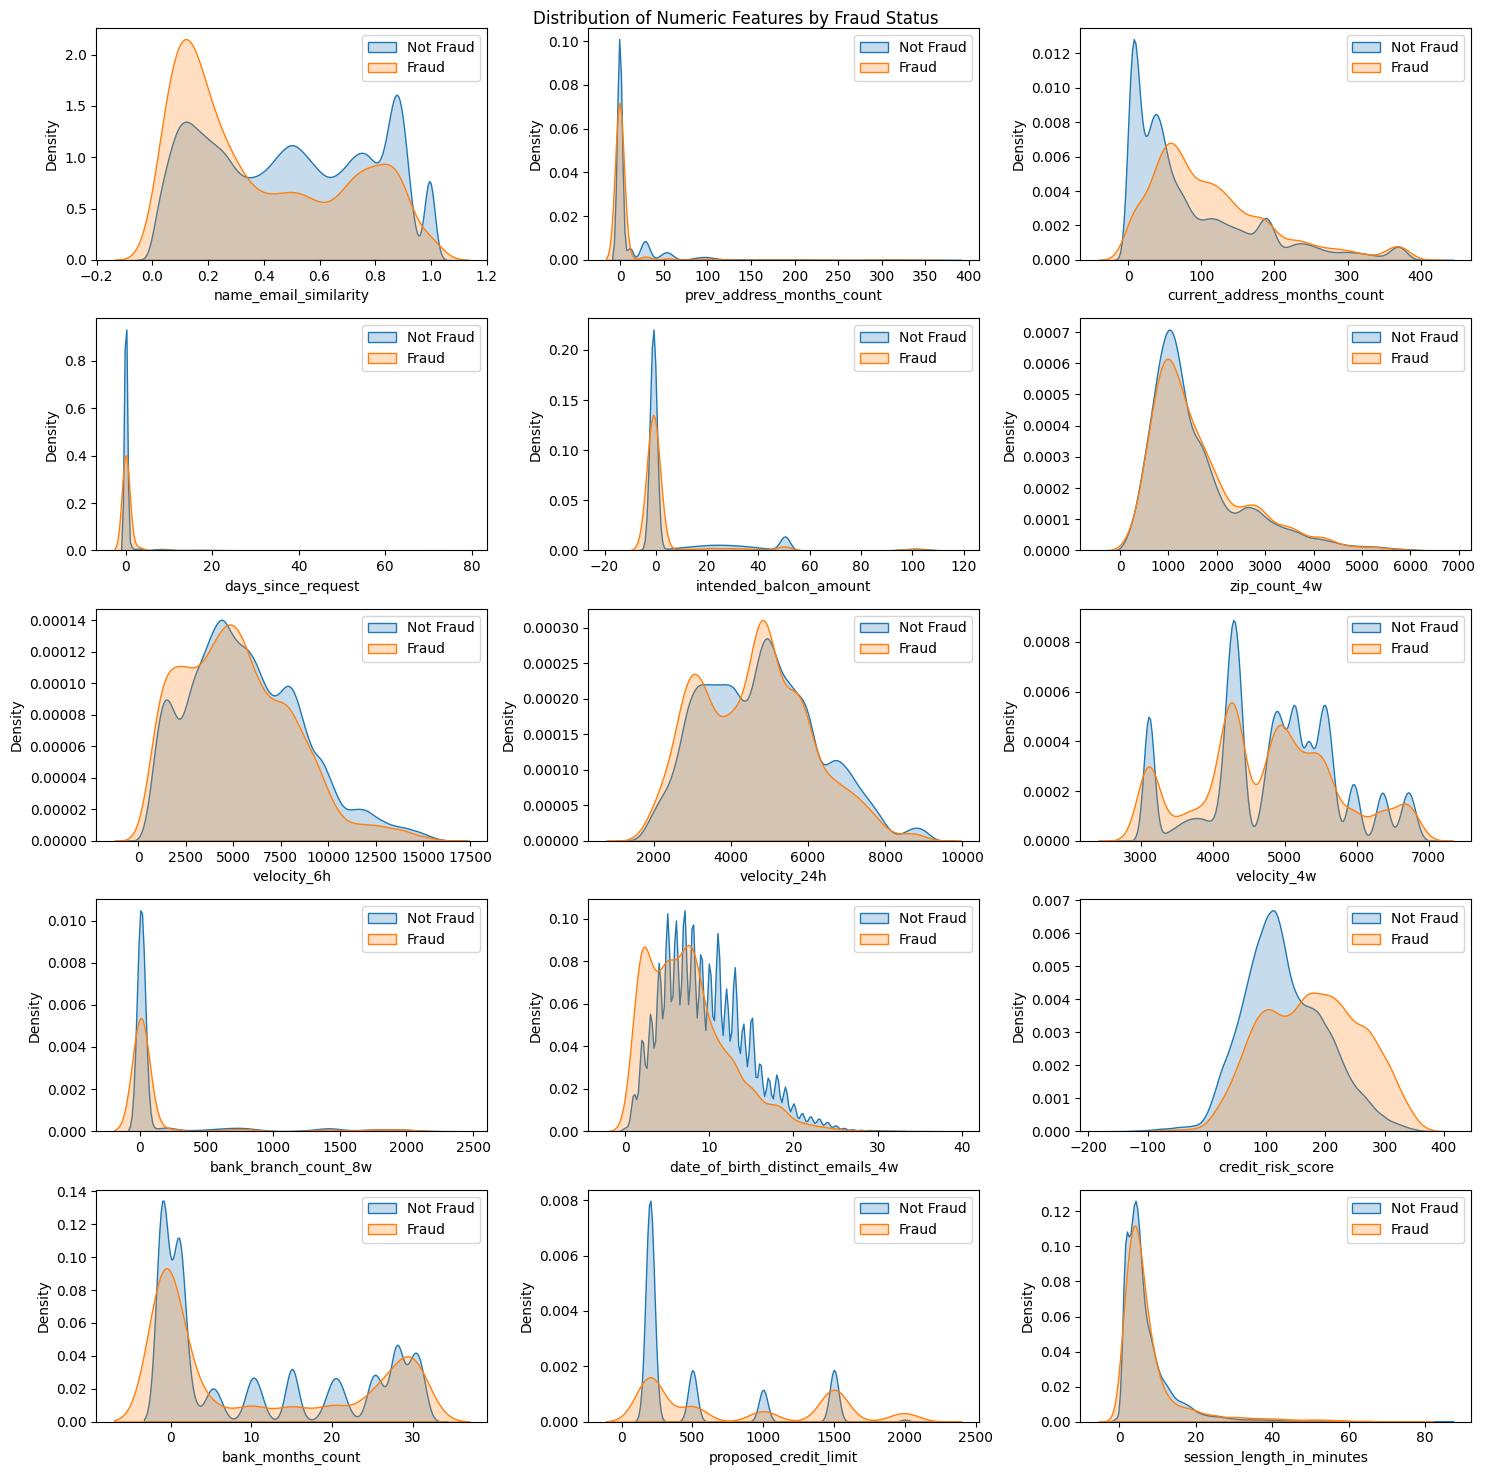

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Add a title to the figure
fig.suptitle('Distribution of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a kernel density plot for each feature
for i, feature in enumerate(numeric_features):
    ax = axes[i // 3][i % 3]
    sns.kdeplot(data=df[df['fraud_bool'] == 0][feature], fill=True, ax=ax, label='Not Fraud')
    sns.kdeplot(data=df[df['fraud_bool'] == 1][feature], fill=True, ax=ax, label='Fraud')
    ax.set_xlabel(feature)
    ax.legend()

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

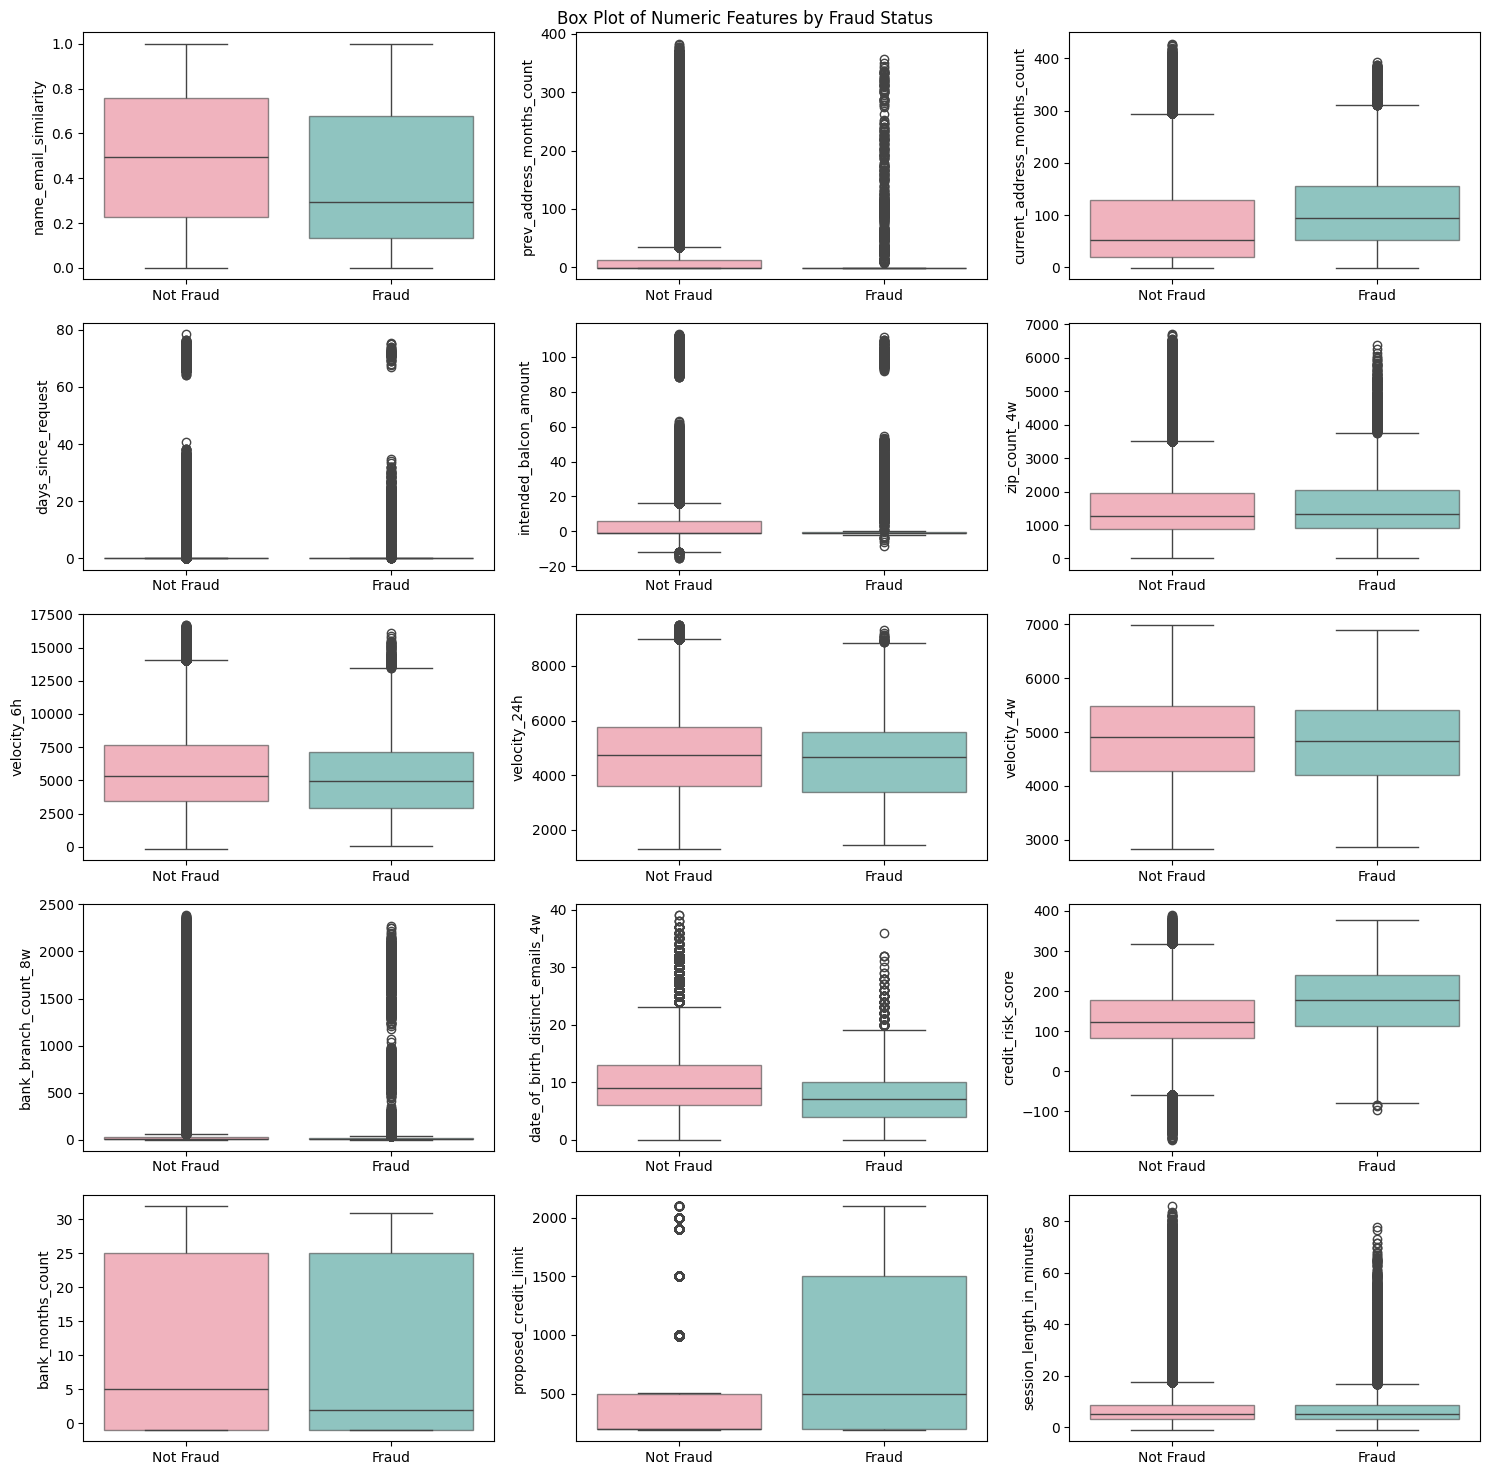

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom color palette (re-added for robustness)
my_palette = sns.color_palette("husl", 2)

# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Add a title to the figure
fig.suptitle('Box Plot of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a box plot for each feature
for i, feature in enumerate(numeric_features):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df, x='fraud_bool', y=feature, hue='fraud_bool', ax=ax, palette=my_palette, legend=False, boxprops=dict(alpha=.6))
    ax.set_xlabel('')
    ax.set_ylabel(feature)
    # Set x-ticks explicitly before setting tick labels to avoid UserWarning
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not Fraud', 'Fraud'])

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
### 1.1 Number of Transactions by Fraud Status
# Create a new DataFrame showing the count of unique values in the 'fraud_bool' column
fraud_vals = pd.DataFrame(df['fraud_bool'].value_counts())
print(fraud_vals)

             count
fraud_bool        
0           988971
1            11029


In [ ]:
# Create a new DataFrame showing the count of unique values in the 'fraud_bool' column
# and reset the index to make fraud_bool a regular column.
# Then explicitly name the columns for clarity.
fraud_vals = df['fraud_bool'].value_counts().reset_index()
fraud_vals.columns = ['fraud_status', 'count'] # Assign clear column names
print(fraud_vals)

   fraud_status   count
0             0  988971
1             1   11029


In [ ]:
import seaborn as sns
# Define custom color palette
my_palette = sns.color_palette("husl", 2)
sns.set_style("whitegrid")

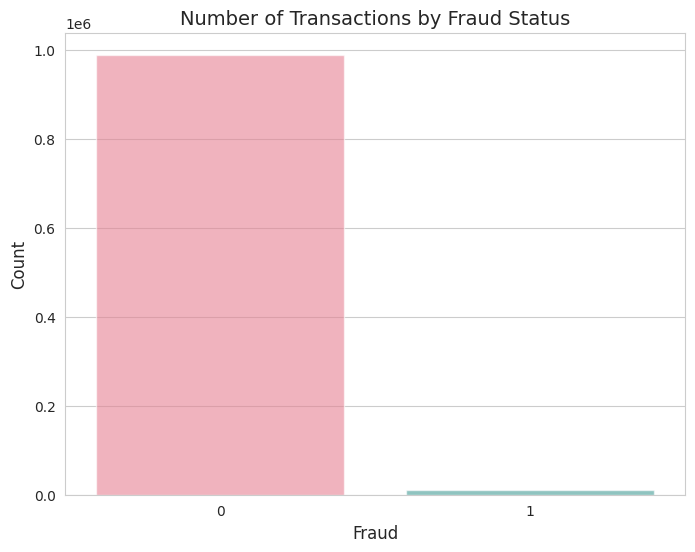

In [ ]:
import matplotlib.pyplot as plt
# Set up plot
plt.figure(figsize=(8, 6))

# Create bar plot
sns.barplot(data=fraud_vals, x="fraud_status", y="count", hue="fraud_status", palette=my_palette, alpha=.6, legend=False)

# Customize labels and legend
plt.xlabel("Fraud", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title("Number of Transactions by Fraud Status", fontsize=14)

# Display plot
plt.show()

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is also imported if not already

# Initialize an empty DataFrame to hold the percentage of missing values for each feature
missing_vals = pd.DataFrame()

# List of features to check for missing values
missing_features = ['prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w']

# For each feature, replace -1 values with NaN, calculate the percentage of missing values, and add to the missing_vals DataFrame
for feature in missing_features:
    df.loc[df[feature] < 0, feature] = np.nan # df[feature] = df[feature].replace(-1, np.nan)
    missing_vals_col = df.groupby('fraud_bool')[feature].apply(lambda x: round(x.isna().sum()/len(x) * 100, 2))
    missing_vals[feature] = missing_vals_col

print(missing_vals)

            prev_address_months_count  current_address_months_count  \
fraud_bool                                                            
0                               71.06                          0.43   
1                               91.89                          0.13   

            intended_balcon_amount  bank_months_count  \
fraud_bool                                              
0                            74.09              25.23   
1                            88.38              37.54   

            session_length_in_minutes  device_distinct_emails_8w  
fraud_bool                                                        
0                                0.20                       0.04  
1                                0.16                       0.04  


In [ ]:
# Reshape the missing_vals DataFrame from wide to long format
missing_vals = pd.DataFrame(missing_vals.T.stack())

# Reset the index and rename the columns
missing_vals.reset_index(inplace=True)
missing_vals.rename(columns={'level_0': 'feature', 0: 'missing_vals'}, inplace=True)

print(missing_vals)

                         feature  fraud_bool  missing_vals
0      prev_address_months_count           0         71.06
1      prev_address_months_count           1         91.89
2   current_address_months_count           0          0.43
3   current_address_months_count           1          0.13
4         intended_balcon_amount           0         74.09
5         intended_balcon_amount           1         88.38
6              bank_months_count           0         25.23
7              bank_months_count           1         37.54
8      session_length_in_minutes           0          0.20
9      session_length_in_minutes           1          0.16
10     device_distinct_emails_8w           0          0.04
11     device_distinct_emails_8w           1          0.04


/tmp/ipykernel_4775/2015125928.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Fraud", fontsize=10)


<Figure size 800x600 with 0 Axes>

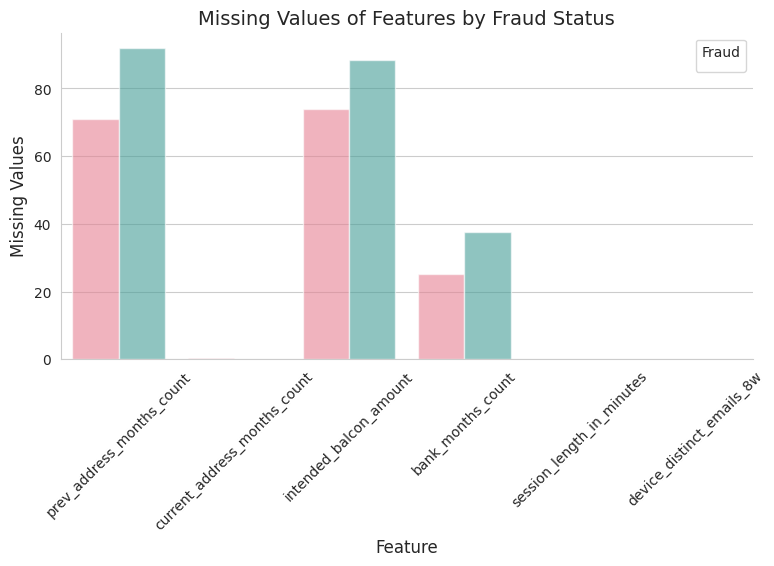

In [ ]:
# Set up plot
plt.figure(figsize=(8, 6))

# Create bar plot
sns.catplot(data=missing_vals, kind="bar", x="feature", y="missing_vals", hue="fraud_bool", palette=my_palette, alpha=.6, height=4, aspect=2, legend=False)

# Customize labels and legend
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Missing Values", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.title("Missing Values of Features by Fraud Status", fontsize=14)
plt.legend(title="Fraud", fontsize=10)

# Display plot
plt.show()

When examining features like prev_address_months_count, intended_balcon_amount, and bank_months_count, it becomes apparent that a considerable number of missing values exist in their original distribution. However, despite these missing values, these features still hold informative value and exhibit correlation with the target feature.

It's important to highlight that the missing values in these features are actually represented by negative values and were not transformed into explicit missing values during preprocessing. The potential impact of such a transformation has not been evaluated, as it could potentially result in information loss, even though negative values themselves do not possess any specific meaning.

Now that the categorical variables are encoded, we can prepare the data for a predictive model. We'll separate the features (X) from the target variable (fraud_bool, y) and then split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('fraud_bool', axis=1)
y = df_encoded['fraud_bool']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (700000, 73)
X_test shape: (300000, 73)
y_train shape: (700000,)
y_test shape: (300000,)


### Scaling Numerical Features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns for scaling (excluding target and temporary z-score columns)
numerical_cols_to_scale = [col for col in X_train.select_dtypes(include=np.number).columns if not col.endswith('_zscore')]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features scaled using MinMaxScaler.")
display(X_train[numerical_cols_to_scale].head())

Numerical features scaled using MinMaxScaler.


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
533494,0.000,0.242895,0.074271,0.441589,0.375,0.000133,0.115022,0.194059,0.238593,0.598360,...,1.0,0.935484,0.0,0.005236,0.0,0.093379,0.0,0.666667,0.0,0.428571
172378,0.000,0.996539,0.074271,0.586449,0.125,0.000263,0.109899,0.564860,0.231113,0.491819,...,1.0,0.774194,0.0,0.005236,0.0,0.106189,0.0,0.666667,0.0,0.142857
816133,0.750,0.339912,0.074271,0.200935,0.000,0.000235,0.118040,0.115540,0.480903,0.257759,...,1.0,0.451613,0.0,0.005236,0.0,0.082530,0.0,0.666667,0.0,0.857143
562677,0.625,0.077988,0.074271,0.315421,0.500,0.000099,0.110615,0.198686,0.471888,0.358429,...,1.0,0.967742,0.0,0.005236,0.0,0.072642,1.0,0.666667,0.0,0.571429
287640,0.875,0.322449,0.135279,0.018692,0.750,0.000059,0.113516,0.194954,0.304492,0.440577,...,1.0,0.129032,0.0,0.005236,1.0,0.228234,1.0,0.666667,0.0,0.285714


### Binning `customer_age` and `credit_risk_score`

In [ ]:
# Binning for customer_age
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
X_train['customer_age_binned'] = pd.cut(X_train['customer_age'], bins=age_bins, labels=age_labels, right=False)
X_test['customer_age_binned'] = pd.cut(X_test['customer_age'], bins=age_bins, labels=age_labels, right=False)

# Binning for credit_risk_score
credit_bins = [0, 100, 200, 300, 400, 500]
credit_labels = ['<100', '100-199', '200-299', '300-399', '400+']
X_train['credit_risk_score_binned'] = pd.cut(X_train['credit_risk_score'], bins=credit_bins, labels=credit_labels, right=False)
X_test['credit_risk_score_binned'] = pd.cut(X_test['credit_risk_score'], bins=credit_bins, labels=credit_labels, right=False)

# One-hot encode the binned features
X_train = pd.get_dummies(X_train, columns=['customer_age_binned', 'credit_risk_score_binned'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['customer_age_binned', 'credit_risk_score_binned'], drop_first=True)

print("Customer age and credit risk score binned and one-hot encoded.")
display(X_train[['customer_age', 'customer_age_binned_25-34', 'customer_age_binned_35-44']].head())

Customer age and credit risk score binned and one-hot encoded.


,customer_age,customer_age_binned_25-34,customer_age_binned_35-44
533494,0.375,False,False
172378,0.125,False,False
816133,0.000,False,False
562677,0.500,False,False
287640,0.750,False,False


### Domain-Derived Features

In [ ]:
# Velocity Ratios
X_train['velocity_ratio_6h_24h'] = X_train['velocity_6h'] / (X_train['velocity_24h'] + 1e-6) # Add a small epsilon to avoid division by zero
X_test['velocity_ratio_6h_24h'] = X_test['velocity_6h'] / (X_test['velocity_24h'] + 1e-6)

X_train['velocity_ratio_24h_4w'] = X_train['velocity_24h'] / (X_train['velocity_4w'] + 1e-6)
X_test['velocity_ratio_24h_4w'] = X_test['velocity_24h'] / (X_test['velocity_4w'] + 1e-6)

# Interaction terms (example)
X_train['income_x_credit_score'] = X_train['income'] * X_train['credit_risk_score']
X_test['income_x_credit_score'] = X_test['income'] * X_test['credit_risk_score']

print("Domain-derived features created.")
display(X_train[['velocity_ratio_6h_24h', 'velocity_ratio_24h_4w', 'income_x_credit_score']].head())

Domain-derived features created.


,velocity_ratio_6h_24h,velocity_ratio_24h_4w,income_x_credit_score
533494,0.398744,1.227209,0.000000
172378,0.469914,0.740673,0.000000
816133,1.865699,0.300736,0.422801
562677,1.316541,0.665197,0.341113
287640,0.691121,0.663805,0.512118


## Model Training: LightGBM

Now that our data is preprocessed and feature-engineered, we can proceed with training a machine learning model. We will use LightGBM, a gradient boosting framework that uses tree-based learning algorithms. It is designed to be distributed and efficient, often outperforming other gradient boosting frameworks in terms of speed and accuracy.

In [ ]:
import lightgbm as lgb

# Initialize the LightGBM Classifier
# Using parameters that often perform well, focusing on dealing with imbalanced data
lgbm = lgb.LGBMClassifier(objective='binary',
                          metric='auc',
                          is_unbalance=True, # Handles imbalanced datasets by re-weighting
                          n_estimators=1000,
                          learning_rate=0.05,
                          num_leaves=31,
                          max_depth=-1,
                          seed=42,
                          n_jobs=-1, # Use all available cores
                          colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
                          subsample=0.8 # Subsample ratio of the training instance
                         )

print("Training LightGBM model...")
# Train the model
lgbm.fit(X_train, y_train)
print("LightGBM model training complete.")

Training LightGBM model...
[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.299302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7186
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
LightGBM model training complete.


## Model Evaluation

After training our LightGBM model, it's crucial to evaluate its performance on unseen data to understand how well it generalizes. We will use several metrics commonly employed in classification tasks, especially for imbalanced datasets like fraud detection:

Accuracy: 0.8925
Precision: 0.0676
Recall: 0.6836
F1-Score: 0.1230
AUC: 0.8860


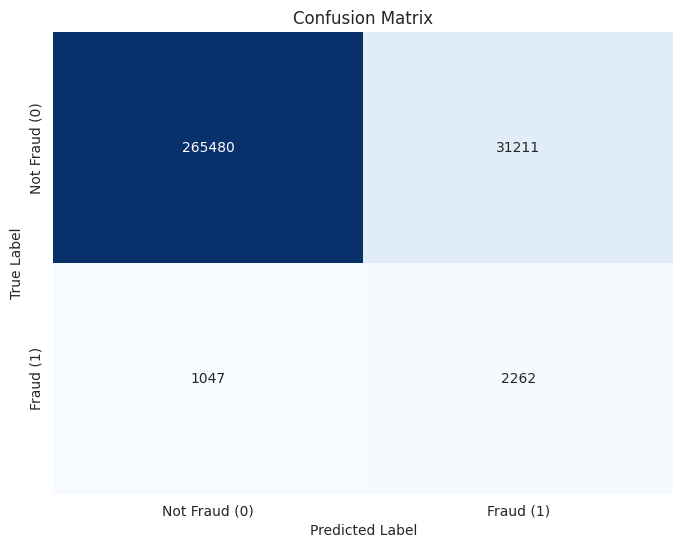

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities on the test set
y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

# Predict class labels on the test set (using default threshold of 0.5)
y_pred = lgbm.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Feature Importance

Understanding which features contribute most to the model's predictions is crucial for interpretability and further feature engineering. We will extract feature importances from the trained LightGBM model and visualize the top contributing features.

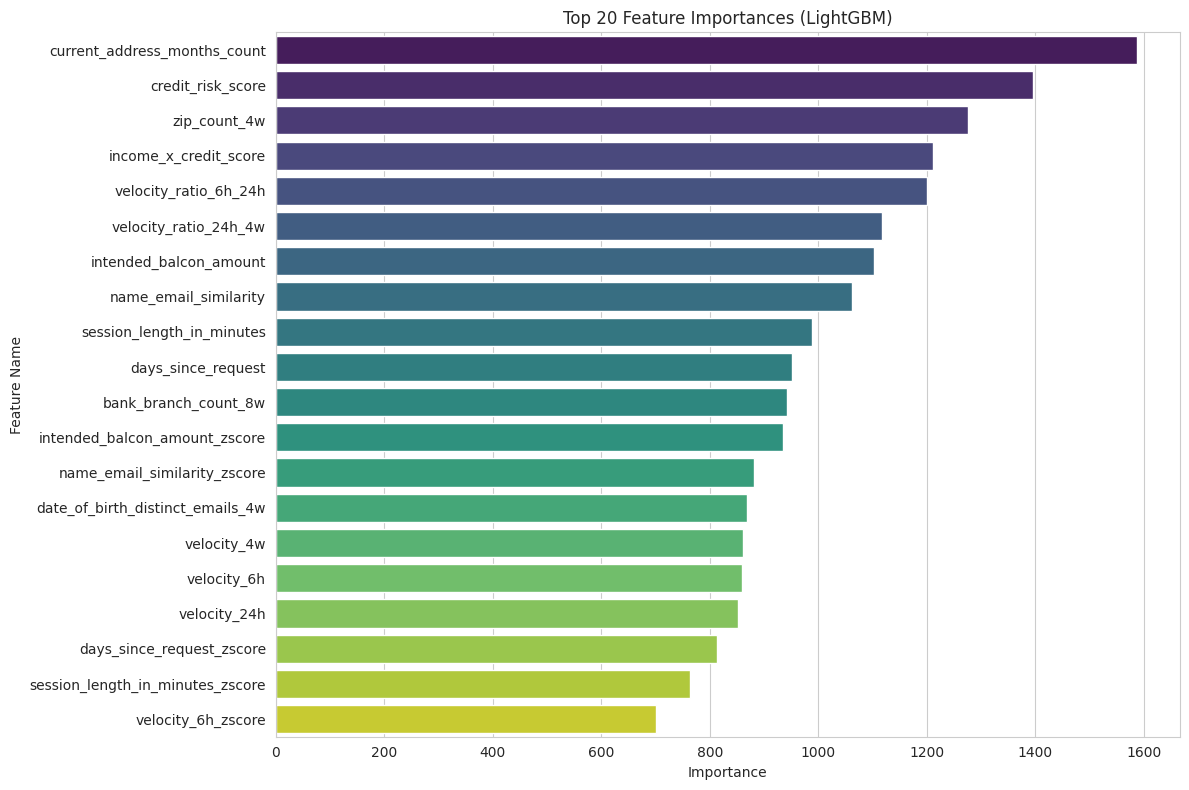

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained LightGBM model
feature_importances = lgbm.feature_importances_
feature_names = X_train.columns # Use X_train columns for feature names

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select the top N features to plot
top_n = 20 # You can adjust this number
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', hue='Feature', legend=False)
plt.title(f'Top {top_n} Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## Model Explainability with SHAP (SHapley Additive exPlanations)

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations, providing an interpretation of how much each feature contributes to the prediction for a specific instance. We will use SHAP to understand the global and local feature importances of our LightGBM model.

In [ ]:
import shap

# Initialize JS for SHAP plots in notebooks
shap.initjs()

# Create a SHAP explainer for the LightGBM model
# Initialize without providing X_train as background data to avoid the 'TreeEnsemble' AttributeError
# SHAP will infer the expected_value directly from the model structure.
explainer = shap.TreeExplainer(lgbm.booster_)

# Calculate SHAP values for the test set
# This can be computationally intensive for large datasets.
# For demonstration, we can sample a subset of X_test.
# For full analysis, consider running on the entire X_test if resources allow.

# Sampling 5000 instances from X_test for SHAP calculation to manage computation time
sampled_X_test = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(sampled_X_test)

print("SHAP values calculated.")

SHAP values calculated.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


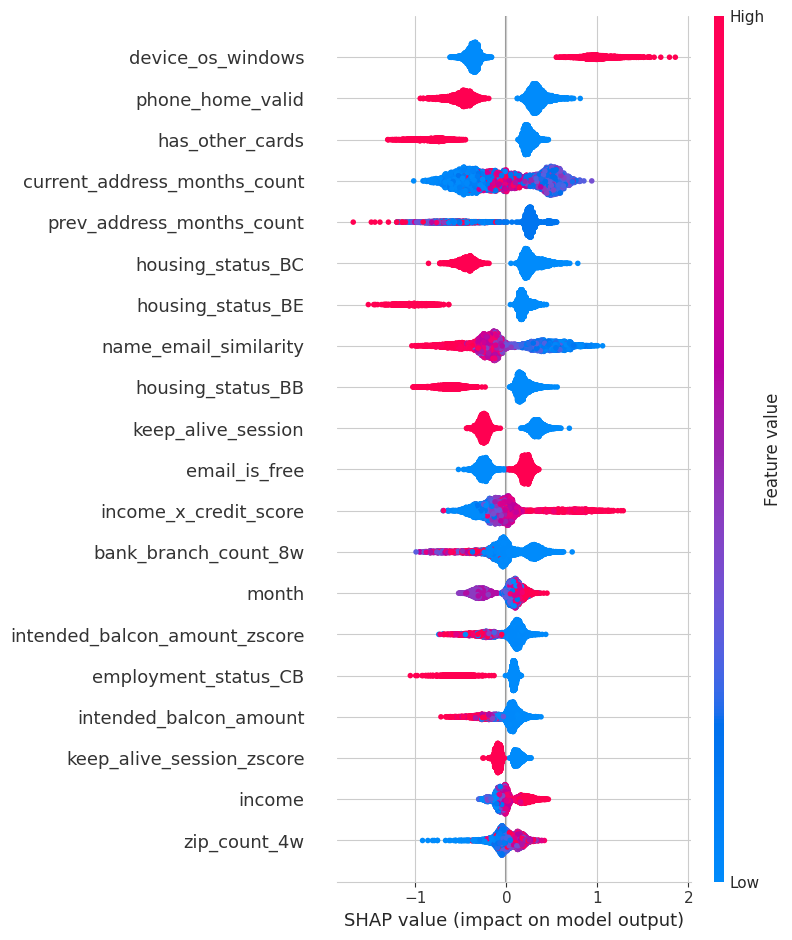

In [ ]:
# Plot the SHAP summary plot
# The `shap_values` variable from `explainer.shap_values` is already a matrix of SHAP values for all samples.
# Passing `shap_values[1]` attempts to plot only the second sample's SHAP values, which is a vector.
# We need to pass the entire matrix of SHAP values for the summary plot.
shap.summary_plot(shap_values, sampled_X_test, plot_type="dot")

### SHAP Summary Plot (Overall Feature Importance)

The SHAP summary plot combines feature importance with feature effects. Each dot represents a single prediction. The position of each dot on the x-axis indicates the SHAP value (impact on model output). The color indicates the feature value (red = high, blue = low). Overlapping dots are stacked, showing the distribution of SHAP values for each feature.

### Feature Importance and Explainability with SHAP

SHAP (SHapley Additive exPlanations) is a powerful method to explain the output of any machine learning model. It connects game theory with local explanations, assigning each feature an importance value for a particular prediction. Here, we'll use SHAP to understand which features are most influential in our LightGBM model's predictions of fraud.

Calculating SHAP values...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP values calculated. Generating summary plot...


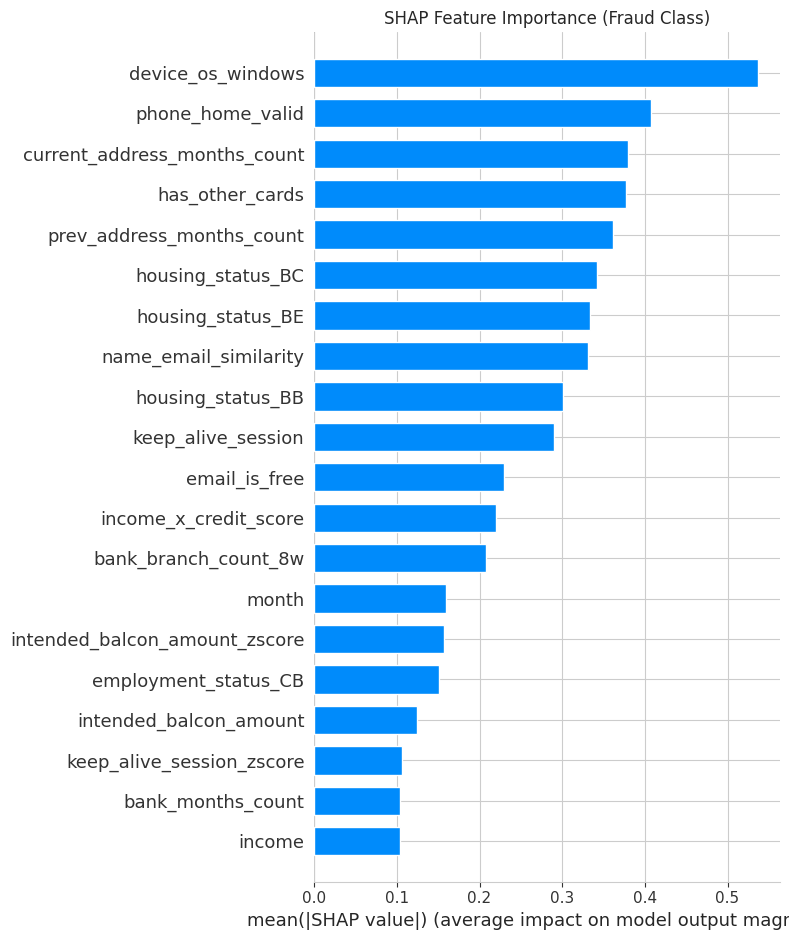

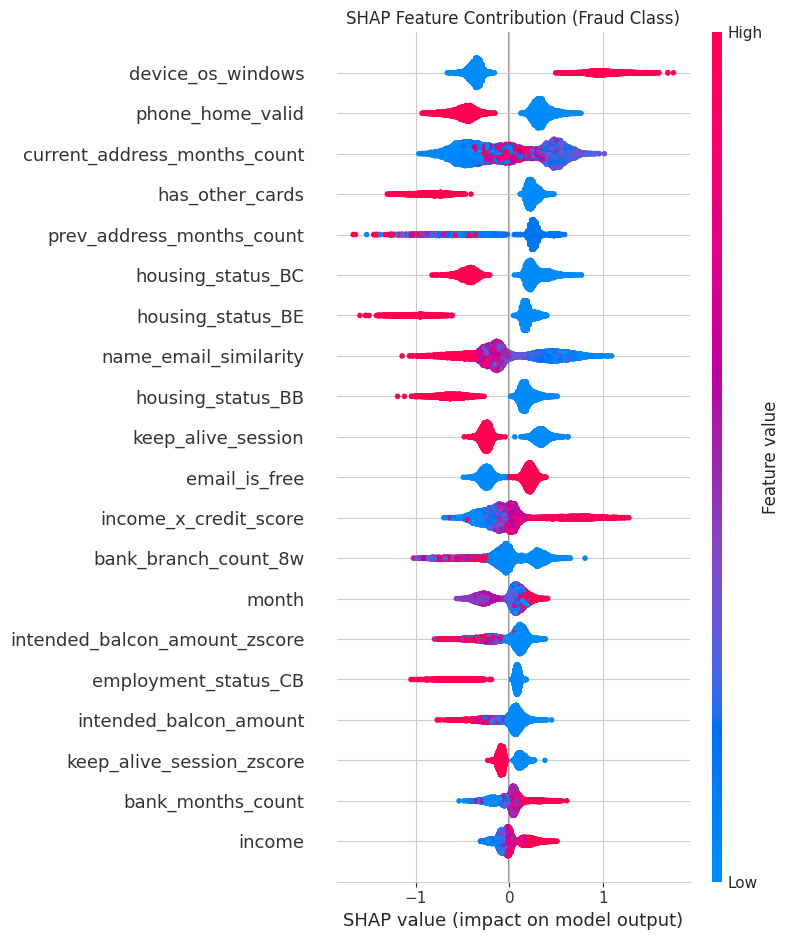

In [ ]:
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP values...")
# Create a SHAP explainer object for the LightGBM model
explainer = shap.TreeExplainer(lgbm)

# Calculate SHAP values for a subset of the training data for faster computation
# Using X_train for explanation as X_test is reserved for final evaluation
X_sample = X_train.sample(n=10000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated. Generating summary plot...")

# Plot the SHAP summary plot
# The previous code was `shap_values[1]`, which for a single ndarray (as seen in kernel state)
# results in a 1D array (vector), causing the AssertionError.
# Correcting to pass the entire 2D shap_values array.
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Fraud Class)')
plt.tight_layout()
plt.show()

# Also plot the SHAP summary dot plot for more detail
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Contribution (Fraud Class)')
plt.tight_layout()
plt.show()

## Feature Selection with `SelectFromModel`

To identify a subset of the most relevant features, we'll use `SelectFromModel` from `scikit-learn` in conjunction with our trained `LightGBM` model. This method uses the feature importances (or coefficients) from a fitted model to determine which features to keep, effectively acting as an embedded feature selection technique. We will select features whose importance is greater than a certain threshold (e.g., the mean importance).

In [ ]:
from sklearn.feature_selection import SelectFromModel
import numpy as np

# Get the feature importances from the trained LightGBM model
feature_importances = lgbm.feature_importances_

# Set a threshold for feature selection. A common choice is the mean importance.
threshold = np.mean(feature_importances)

# Initialize SelectFromModel with the LightGBM model and the chosen threshold
# prefit=True is used because the model is already trained
selector = SelectFromModel(lgbm, threshold=threshold, prefit=True)

# Transform the training and test data to select features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the names of the selected features
selected_features_mask = selector.get_support()
selected_feature_names = X_train.columns[selected_features_mask]

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after selection: {X_train_selected.shape[1]}")
print("\nSelected features:")
for feature in selected_feature_names:
    print(f"- {feature}")

# Convert the transformed arrays back to DataFrames for easier handling
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names, index=X_train.index)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names, index=X_test.index)

print("\nHead of X_train_selected_df:")
display(X_train_selected_df.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Original number of features: 85
Number of features after selection: 29

Selected features:
- name_email_similarity
- prev_address_months_count
- current_address_months_count
- customer_age
- days_since_request
- intended_balcon_amount
- zip_count_4w
- velocity_6h
- velocity_24h
- velocity_4w
- bank_branch_count_8w
- date_of_birth_distinct_emails_4w
- credit_risk_score
- bank_months_count
- session_length_in_minutes
- month
- name_email_similarity_zscore
- current_address_months_count_zscore
- days_since_request_zscore
- intended_balcon_amount_zscore
- zip_count_4w_zscore
- velocity_6h_zscore
- velocity_24h_zscore
- velocity_4w_zscore
- credit_risk_score_zscore
- session_length_in_minutes_zscore
- velocity_ratio_6h_24h
- velocity_ratio_24h_4w
- income_x_credit_score

Head of X_train_selected_df:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,...,intended_balcon_amount_zscore,zip_count_4w_zscore,velocity_6h_zscore,velocity_24h_zscore,velocity_4w_zscore,credit_risk_score_zscore,session_length_in_minutes_zscore,velocity_ratio_6h_24h,velocity_ratio_24h_4w,income_x_credit_score
533494,0.242895,0.074271,0.441589,0.375,0.000133,0.115022,0.194059,0.238593,0.598360,0.487577,...,-0.465164,-0.270240,-0.600450,0.979606,0.023516,-0.286870,-0.084792,0.398744,1.227209,0.000000
172378,0.996539,0.074271,0.586449,0.125,0.000263,0.109899,0.564860,0.231113,0.491819,0.664015,...,-0.497693,2.200482,-0.642419,0.389959,0.815893,-1.449297,0.049493,0.469914,0.740673,0.000000
816133,0.339912,0.074271,0.200935,0.000,0.000235,0.118040,0.115540,0.480903,0.257759,0.857094,...,-0.446003,-0.793428,0.759197,-0.905429,1.683003,0.186712,-0.198530,1.865699,0.300736,0.422801
562677,0.077988,0.074271,0.315421,0.500,0.000099,0.110615,0.198686,0.471888,0.358429,0.538831,...,-0.493145,-0.239405,0.708613,-0.348277,0.253696,0.043202,-0.302189,1.316541,0.665197,0.341113
287640,0.322449,0.135279,0.018692,0.750,0.000059,0.113516,0.194954,0.304492,0.440577,0.663713,...,-0.474727,-0.264272,-0.230676,0.106362,0.814537,0.358923,1.328930,0.691121,0.663805,0.512118


The `SelectFromModel` method has identified a subset of features that are considered most important by the LightGBM model based on their importance scores. This reduced set of features can now be used for subsequent model training, potentially leading to a simpler model, faster training times, and reduced overfitting, while retaining predictive power.

## Compare Performance Metrics: Original vs. Selected Features Model

After training a new LightGBM model (`lgbm_selected`) with the features chosen by `SelectFromModel`, it's crucial to evaluate its performance on the test set (`X_test_selected`). We will compare the metrics of this new model against the original model trained on the full feature set to determine if feature selection has led to improvements in accuracy, precision, recall, F1-score, or AUC.

In [ ]:
import lightgbm as lgb

# Initialize a new LightGBM Classifier with the same parameters
# Using parameters that often perform well, focusing on dealing with imbalanced data
lgbm_selected = lgb.LGBMClassifier(objective='binary',
                                   metric='auc',
                                   is_unbalance=True, # Handles imbalanced datasets by re-weighting
                                   n_estimators=1000,
                                   learning_rate=0.05,
                                   num_leaves=31,
                                   max_depth=-1,
                                   seed=42,
                                   n_jobs=-1, # Use all available cores
                                   colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
                                   subsample=0.8 # Subsample ratio of the training instance
                                  )

print("Training LightGBM model with selected features...")
# Train the new model using the selected features
lgbm_selected.fit(X_train_selected_df, y_train)
print("LightGBM model training with selected features complete.")

Training LightGBM model with selected features...
[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
LightGBM model training with selected features complete.


Evaluating LightGBM model with selected features...

--- Model Performance Comparison ---


,Metric,Original Model,Selected Features Model
0,Accuracy,0.8925,0.852917
1,Precision,0.0676,0.043588
2,Recall,0.6836,0.589000
3,F1-Score,0.1230,0.081169
4,AUC,0.8860,0.814395



Confusion Matrix for Selected Features Model:


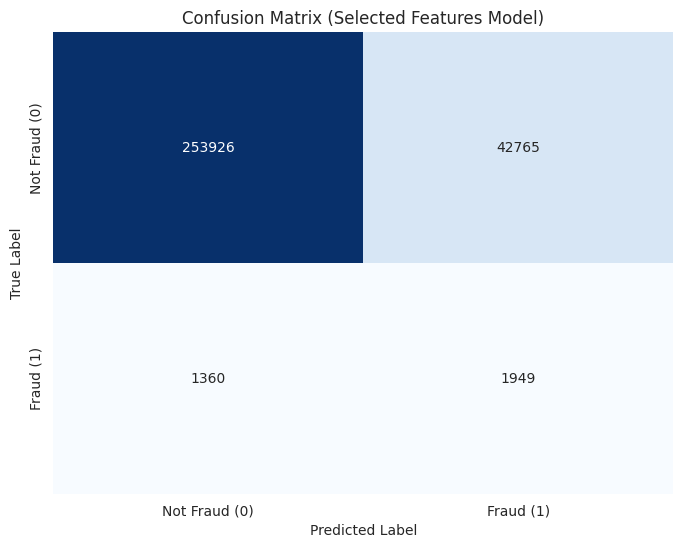

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Evaluate lgbm_selected model (with selected features) ---
print("Evaluating LightGBM model with selected features...")
y_pred_proba_selected = lgbm_selected.predict_proba(X_test_selected_df)[:, 1]
y_pred_selected = lgbm_selected.predict(X_test_selected_df)

accuracy_selected = accuracy_score(y_test, y_pred_selected)
precision_selected = precision_score(y_test, y_pred_selected)
recall_selected = recall_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected)
auc_selected = roc_auc_score(y_test, y_pred_proba_selected)

# --- Original model metrics (from previous execution) ---
# These values are retrieved from the kernel state or previous outputs
accuracy_original = 0.8925
precision_original = 0.0676
recall_original = 0.6836
f1_original = 0.1230
auc_original = 0.8860

# Create a DataFrame for comparison
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Original Model': [accuracy_original, precision_original, recall_original, f1_original, auc_original],
    'Selected Features Model': [accuracy_selected, precision_selected, recall_selected, f1_selected, auc_selected]
}
comparison_df = pd.DataFrame(metrics_data)

print("\n--- Model Performance Comparison ---")
display(comparison_df)

# --- Confusion Matrix for lgbm_selected ---
print("\nConfusion Matrix for Selected Features Model:")
cm_selected = confusion_matrix(y_test, y_pred_selected)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_selected, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Selected Features Model)')
plt.show()

The comparison table and the confusion matrix for the model with selected features provide insights into how feature selection has impacted performance. We can now analyze if the reduced feature set has led to a more efficient model without significant loss in predictive power, or perhaps even an improvement.

## Re-training Model with Selected Features

Now that we have performed feature selection and reduced our feature set, we will retrain the LightGBM model using only these selected features. This step is crucial to assess the impact of feature selection on model performance, efficiency, and interpretability.

In [ ]:
import lightgbm as lgb

# Initialize a new LightGBM Classifier with the same parameters
# Using parameters that often perform well, focusing on dealing with imbalanced data
lgbm_selected = lgb.LGBMClassifier(objective='binary',
                                   metric='auc',
                                   is_unbalance=True, # Handles imbalanced datasets by re-weighting
                                   n_estimators=1000,
                                   learning_rate=0.05,
                                   num_leaves=31,
                                   max_depth=-1,
                                   seed=42,
                                   n_jobs=-1, # Use all available cores
                                   colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
                                   subsample=0.8 # Subsample ratio of the training instance
                                  )

print("Training LightGBM model with selected features...")
# Train the new model using the selected features
lgbm_selected.fit(X_train_selected_df, y_train)
print("LightGBM model training with selected features complete.")

Training LightGBM model with selected features...
[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036596 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
LightGBM model training with selected features complete.


## Hyperparameter Tuning with Optuna

Given that the performance of the model with selected features decreased, we will now perform hyperparameter tuning to find an optimal set of parameters for the LightGBM model. We will use `Optuna`, a popular hyperparameter optimization framework, to search for the best parameters that maximize the AUC score on our test set.

In [ ]:
# Install Optuna for hyperparameter optimization
!pip install optuna
print("Optuna installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.2 MB/s eta 0:00:00
Optuna installed successfully.


In [ ]:
# Install Optuna for hyperparameter optimization
!pip install optuna
print("Optuna installed successfully.")

Optuna installed successfully.


In [ ]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

def objective(trial):
    """Defines the objective function for Optuna to optimize LightGBM hyperparameters."""
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'is_unbalance': True,
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
    }

    # Initialize and train the LightGBM model with the current set of hyperparameters
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_selected_df, y_train)

    # Predict probabilities on the test set
    y_pred_proba = model.predict_proba(X_test_selected_df)[:, 1]

    # Calculate AUC score (objective to maximize)
    auc = roc_auc_score(y_test, y_pred_proba)
    return auc

print("Objective function for Optuna defined.")

Objective function for Optuna defined.


In [ ]:
# Create an Optuna study and optimize the objective function
print("Starting Optuna hyperparameter optimization study...")
study = optuna.create_study(direction='maximize') # Maximize AUC
study.optimize(objective, n_trials=50) # You can adjust n_trials for more comprehensive search

print("Optuna study complete.")
print(f"Best trial:")
print(f"  Value: {study.best_value:.4f}")
print(f"  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-08-15 16:11:52,610] A new study created in memory with name: no-name-e53b0753-0dea-482c-956a-d6f69ed5333d


Starting Optuna hyperparameter optimization study...
[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.070047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:12:20,877] Trial 0 finished with value: 0.7889776109199083 and parameters: {'n_estimators': 1062, 'learning_rate': 0.0866374476261761, 'num_leaves': 52, 'max_depth': 12, 'min_child_samples': 287, 'subsample': 0.8344183606238467, 'colsample_bytree': 0.906804379308356, 'reg_alpha': 3.5260334710751716e-07, 'reg_lambda': 3.886735536844742e-05}. Best is trial 0 with value: 0.7889776109199083.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

[I 2026-08-15 16:12:23,488] Trial 1 finished with value: 0.819734707468996 and parameters: {'n_estimators': 112, 'learning_rate': 0.012496868877266632, 'num_leaves': 99, 'max_depth': 5, 'min_child_samples': 46, 'subsample': 0.9801642763763871, 'colsample_bytree': 0.6691152166181137, 'reg_alpha': 5.7444838521130705e-05, 'reg_lambda': 1.3923982138395197e-07}. Best is trial 1 with value: 0.819734707468996.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:12:50,718] Trial 2 finished with value: 0.7995442862607747 and parameters: {'n_estimators': 1726, 'learning_rate': 0.07750304835406747, 'num_leaves': 24, 'max_depth': 18, 'min_child_samples': 176, 'subsample': 0.9794640691828014, 'colsample_bytree': 0.6514043665474062, 'reg_alpha': 0.00160913708673502, 'reg_lambda': 0.10617378755578673}. Best is trial 1 with value: 0.819734707468996.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037813 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:13:16,790] Trial 3 finished with value: 0.8294139297521472 and parameters: {'n_estimators': 1081, 'learning_rate': 0.016510810601695677, 'num_leaves': 50, 'max_depth': 20, 'min_child_samples': 396, 'subsample': 0.7706342513781407, 'colsample_bytree': 0.8066723368012143, 'reg_alpha': 5.022891471127941e-05, 'reg_lambda': 0.04518359563972239}. Best is trial 3 with value: 0.8294139297521472.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:13:37,463] Trial 4 finished with value: 0.8257655853604903 and parameters: {'n_estimators': 724, 'learning_rate': 0.024571529755523375, 'num_leaves': 79, 'max_depth': 18, 'min_child_samples': 317, 'subsample': 0.9867979205333722, 'colsample_bytree': 0.7089220201494075, 'reg_alpha': 0.01791637889332543, 'reg_lambda': 0.969573803779078}. Best is trial 3 with value: 0.8294139297521472.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037849 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:13:56,938] Trial 5 finished with value: 0.8288415725298945 and parameters: {'n_estimators': 522, 'learning_rate': 0.01322542472029683, 'num_leaves': 95, 'max_depth': 9, 'min_child_samples': 290, 'subsample': 0.9736809763764467, 'colsample_bytree': 0.6148592531619003, 'reg_alpha': 4.461401488804999e-07, 'reg_lambda': 2.756095514901327e-05}. Best is trial 3 with value: 0.8294139297521472.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:14:23,991] Trial 6 finished with value: 0.8280001754702409 and parameters: {'n_estimators': 1404, 'learning_rate': 0.024250334210688902, 'num_leaves': 27, 'max_depth': 14, 'min_child_samples': 394, 'subsample': 0.720831176171251, 'colsample_bytree': 0.6710453513909859, 'reg_alpha': 0.0018500482117764846, 'reg_lambda': 9.477585756658639e-05}. Best is trial 3 with value: 0.8294139297521472.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:15:05,112] Trial 7 finished with value: 0.8297653886954552 and parameters: {'n_estimators': 1990, 'learning_rate': 0.015363339747128713, 'num_leaves': 21, 'max_depth': 7, 'min_child_samples': 282, 'subsample': 0.7008392793133497, 'colsample_bytree': 0.9940985630310499, 'reg_alpha': 0.08843707202499002, 'reg_lambda': 1.8683476127141722e-08}. Best is trial 7 with value: 0.8297653886954552.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-08-15 16:15:39,341] Trial 8 finished with value: 0.8003311603036698 and parameters: {'n_estimators': 1421, 'learning_rate': 0.0591995829890069, 'num_leaves': 42, 'max_depth': 9, 'min_child_samples': 489, 'subsample': 0.929518136742976, 'colsample_bytree': 0.9580986526104823, 'reg_alpha': 0.0005610245275649669, 'reg_lambda': 0.016080354118364882}. Best is trial 7 with value: 0.8297653886954552.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:16:12,433] Trial 9 finished with value: 0.7969537411571259 and parameters: {'n_estimators': 1807, 'learning_rate': 0.062447057263110076, 'num_leaves': 36, 'max_depth': 18, 'min_child_samples': 373, 'subsample': 0.6093492342621815, 'colsample_bytree': 0.8079222364928712, 'reg_alpha': 0.00651339239736097, 'reg_lambda': 3.624047903680408e-07}. Best is trial 7 with value: 0.8297653886954552.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-08-15 16:16:16,138] Trial 10 finished with value: 0.8229662234586503 and parameters: {'n_estimators': 153, 'learning_rate': 0.03828518776591195, 'num_leaves': 67, 'max_depth': 5, 'min_child_samples': 154, 'subsample': 0.6111667370011133, 'colsample_bytree': 0.8534651025241208, 'reg_alpha': 0.5447762836198733, 'reg_lambda': 1.0097831022116844e-08}. Best is trial 7 with value: 0.8297653886954552.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:17:09,145] Trial 11 finished with value: 0.8216547049261097 and parameters: {'n_estimators': 1959, 'learning_rate': 0.01865250654874275, 'num_leaves': 56, 'max_depth': 14, 'min_child_samples': 492, 'subsample': 0.7318438297072395, 'colsample_bytree': 0.9945275571144968, 'reg_alpha': 3.674487720938874e-05, 'reg_lambda': 0.0006821605282687223}. Best is trial 7 with value: 0.8297653886954552.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:17:35,805] Trial 12 finished with value: 0.8279128457481366 and parameters: {'n_estimators': 1102, 'learning_rate': 0.017526128714277486, 'num_leaves': 42, 'max_depth': 9, 'min_child_samples': 198, 'subsample': 0.7287199519117985, 'colsample_bytree': 0.7768083698638437, 'reg_alpha': 0.3586903298329106, 'reg_lambda': 1.5512027477850445e-06}. Best is trial 7 with value: 0.8297653886954552.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:18:13,305] Trial 13 finished with value: 0.8323412834376104 and parameters: {'n_estimators': 1494, 'learning_rate': 0.010672623623570307, 'num_leaves': 20, 'max_depth': 20, 'min_child_samples': 410, 'subsample': 0.7992731191482872, 'colsample_bytree': 0.8848146185167469, 'reg_alpha': 1.1765751770334509e-08, 'reg_lambda': 0.002793735521741397}. Best is trial 13 with value: 0.8323412834376104.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:18:49,421] Trial 14 finished with value: 0.8324512166618981 and parameters: {'n_estimators': 1553, 'learning_rate': 0.011619693825256775, 'num_leaves': 20, 'max_depth': 12, 'min_child_samples': 249, 'subsample': 0.8314651187273501, 'colsample_bytree': 0.914379078341971, 'reg_alpha': 2.705991437621124e-08, 'reg_lambda': 0.0019143621007862769}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:19:28,244] Trial 15 finished with value: 0.8310945563146679 and parameters: {'n_estimators': 1473, 'learning_rate': 0.010395107974411458, 'num_leaves': 33, 'max_depth': 15, 'min_child_samples': 55, 'subsample': 0.8536725859639023, 'colsample_bytree': 0.896667810609437, 'reg_alpha': 1.1706442066989193e-08, 'reg_lambda': 0.0018433079975426197}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:20:08,797] Trial 16 finished with value: 0.8299536401874822 and parameters: {'n_estimators': 1594, 'learning_rate': 0.010196496034344226, 'num_leaves': 31, 'max_depth': 12, 'min_child_samples': 129, 'subsample': 0.8415394914568475, 'colsample_bytree': 0.9143122632445736, 'reg_alpha': 1.0138311296371825e-08, 'reg_lambda': 0.0016485655484318425}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:20:34,021] Trial 17 finished with value: 0.8295935874111823 and parameters: {'n_estimators': 1236, 'learning_rate': 0.023502655852399166, 'num_leaves': 21, 'max_depth': 20, 'min_child_samples': 247, 'subsample': 0.7944695222824756, 'colsample_bytree': 0.8603324381720595, 'reg_alpha': 1.4674842813474095e-07, 'reg_lambda': 0.006891689388212025}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:20:54,591] Trial 18 finished with value: 0.8234382547853789 and parameters: {'n_estimators': 829, 'learning_rate': 0.035750389874165255, 'num_leaves': 41, 'max_depth': 16, 'min_child_samples': 442, 'subsample': 0.9065755717494665, 'colsample_bytree': 0.9399949297598922, 'reg_alpha': 3.1479495134741643e-06, 'reg_lambda': 0.00035922777393915055}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:21:33,120] Trial 19 finished with value: 0.8321667533541686 and parameters: {'n_estimators': 1684, 'learning_rate': 0.012624200841300762, 'num_leaves': 20, 'max_depth': 11, 'min_child_samples': 340, 'subsample': 0.8773464687017662, 'colsample_bytree': 0.8600927933657375, 'reg_alpha': 6.312888584789232e-08, 'reg_lambda': 5.91884703985894e-06}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037992 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:22:03,631] Trial 20 finished with value: 0.8319525604447376 and parameters: {'n_estimators': 1250, 'learning_rate': 0.010006544181950272, 'num_leaves': 31, 'max_depth': 16, 'min_child_samples': 234, 'subsample': 0.7934313444152232, 'colsample_bytree': 0.7488514175582572, 'reg_alpha': 2.050686513312805e-06, 'reg_lambda': 0.5358878637719684}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010860 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:22:39,474] Trial 21 finished with value: 0.8318113076546282 and parameters: {'n_estimators': 1661, 'learning_rate': 0.012923165184209868, 'num_leaves': 21, 'max_depth': 11, 'min_child_samples': 340, 'subsample': 0.8784151640107203, 'colsample_bytree': 0.8579903804030808, 'reg_alpha': 4.479841147302515e-08, 'reg_lambda': 2.6733283984803848e-06}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:23:13,384] Trial 22 finished with value: 0.8303555854804698 and parameters: {'n_estimators': 1556, 'learning_rate': 0.013185403204934555, 'num_leaves': 28, 'max_depth': 11, 'min_child_samples': 352, 'subsample': 0.9175126367412889, 'colsample_bytree': 0.8242101045050407, 'reg_alpha': 6.283541507312538e-08, 'reg_lambda': 1.2546396162985222e-05}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:23:50,245] Trial 23 finished with value: 0.8294975721831016 and parameters: {'n_estimators': 1808, 'learning_rate': 0.020182714715207523, 'num_leaves': 20, 'max_depth': 7, 'min_child_samples': 435, 'subsample': 0.8143247333022289, 'colsample_bytree': 0.8829942938226458, 'reg_alpha': 6.664609786957197e-07, 'reg_lambda': 0.00015913302769093507}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:24:22,478] Trial 24 finished with value: 0.828671322556235 and parameters: {'n_estimators': 1268, 'learning_rate': 0.01497733830645241, 'num_leaves': 36, 'max_depth': 13, 'min_child_samples': 244, 'subsample': 0.8821551949736214, 'colsample_bytree': 0.9464074421725629, 'reg_alpha': 4.20395875505078e-08, 'reg_lambda': 0.0034350647960922024}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:25:00,065] Trial 25 finished with value: 0.8302162741204518 and parameters: {'n_estimators': 1804, 'learning_rate': 0.01197329583950802, 'num_leaves': 29, 'max_depth': 10, 'min_child_samples': 417, 'subsample': 0.7711676214078731, 'colsample_bytree': 0.8297902203976114, 'reg_alpha': 4.272774912893096e-06, 'reg_lambda': 0.1233104305859722}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-08-15 16:25:31,091] Trial 26 finished with value: 0.8202421342442906 and parameters: {'n_estimators': 1352, 'learning_rate': 0.03120747812613014, 'num_leaves': 37, 'max_depth': 7, 'min_child_samples': 315, 'subsample': 0.6653342132902526, 'colsample_bytree': 0.9320042914749419, 'reg_alpha': 1.1664592001918134e-08, 'reg_lambda': 0.009716362084380887}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059433 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:26:10,421] Trial 27 finished with value: 0.8309800149950315 and parameters: {'n_estimators': 1571, 'learning_rate': 0.011559395807499708, 'num_leaves': 27, 'max_depth': 17, 'min_child_samples': 353, 'subsample': 0.8779033407664687, 'colsample_bytree': 0.8877356252933178, 'reg_alpha': 1.1347008061711505e-07, 'reg_lambda': 4.478003302939804e-06}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:26:34,957] Trial 28 finished with value: 0.8295361257659799 and parameters: {'n_estimators': 917, 'learning_rate': 0.014745154628675794, 'num_leaves': 47, 'max_depth': 13, 'min_child_samples': 104, 'subsample': 0.9375012136787072, 'colsample_bytree': 0.7692893016497979, 'reg_alpha': 9.418500613127755e-07, 'reg_lambda': 0.0005806573043932347}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010788 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:27:26,905] Trial 29 finished with value: 0.8153635149746226 and parameters: {'n_estimators': 1910, 'learning_rate': 0.02118925276605147, 'num_leaves': 62, 'max_depth': 12, 'min_child_samples': 278, 'subsample': 0.8286572874011507, 'colsample_bytree': 0.915080185285951, 'reg_alpha': 1.8239746160279327e-07, 'reg_lambda': 9.172780658222402e-05}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:28:03,764] Trial 30 finished with value: 0.8317396163250717 and parameters: {'n_estimators': 1496, 'learning_rate': 0.011353051359234865, 'num_leaves': 25, 'max_depth': 10, 'min_child_samples': 459, 'subsample': 0.7672347633342215, 'colsample_bytree': 0.9783151059716342, 'reg_alpha': 1.0369443742495506e-05, 'reg_lambda': 1.832743234236876e-05}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042746 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:28:33,180] Trial 31 finished with value: 0.8320879818144511 and parameters: {'n_estimators': 1256, 'learning_rate': 0.01052155408163272, 'num_leaves': 31, 'max_depth': 16, 'min_child_samples': 240, 'subsample': 0.8017651657718439, 'colsample_bytree': 0.7221867374074549, 'reg_alpha': 1.7040430033506004e-06, 'reg_lambda': 0.8485321122155677}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:28:57,017] Trial 32 finished with value: 0.8321854526058061 and parameters: {'n_estimators': 1163, 'learning_rate': 0.013618291465759571, 'num_leaves': 20, 'max_depth': 19, 'min_child_samples': 200, 'subsample': 0.8568958686047466, 'colsample_bytree': 0.7404018717114685, 'reg_alpha': 2.2587816092338745e-08, 'reg_lambda': 0.3109514931709192}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:29:35,845] Trial 33 finished with value: 0.8302640062062447 and parameters: {'n_estimators': 1680, 'learning_rate': 0.013232867294231383, 'num_leaves': 25, 'max_depth': 19, 'min_child_samples': 198, 'subsample': 0.8536647541980876, 'colsample_bytree': 0.875364115407121, 'reg_alpha': 2.3936167174069966e-08, 'reg_lambda': 0.046980733062967475}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:29:57,025] Trial 34 finished with value: 0.832250639227826 and parameters: {'n_estimators': 975, 'learning_rate': 0.016280908954199685, 'num_leaves': 20, 'max_depth': 19, 'min_child_samples': 195, 'subsample': 0.8947632055778487, 'colsample_bytree': 0.8359808613652752, 'reg_alpha': 2.3361934543884118e-07, 'reg_lambda': 0.16122187850354913}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:30:19,947] Trial 35 finished with value: 0.831234754865457 and parameters: {'n_estimators': 981, 'learning_rate': 0.01656294665008539, 'num_leaves': 25, 'max_depth': 19, 'min_child_samples': 75, 'subsample': 0.9498871130116253, 'colsample_bytree': 0.7825397493441552, 'reg_alpha': 3.387235823056836e-07, 'reg_lambda': 0.19371386495734166}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:30:35,365] Trial 36 finished with value: 0.831201045690509 and parameters: {'n_estimators': 630, 'learning_rate': 0.019201278356547995, 'num_leaves': 34, 'max_depth': 20, 'min_child_samples': 174, 'subsample': 0.9037504835729135, 'colsample_bytree': 0.7003281437796762, 'reg_alpha': 2.4292701610724294e-07, 'reg_lambda': 0.030228751138337947}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038673 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:30:59,027] Trial 37 finished with value: 0.83145233967531 and parameters: {'n_estimators': 1091, 'learning_rate': 0.0147035842696291, 'num_leaves': 24, 'max_depth': 19, 'min_child_samples': 195, 'subsample': 0.8232978964524005, 'colsample_bytree': 0.6087941234660958, 'reg_alpha': 3.1823165479794206e-08, 'reg_lambda': 0.07062847926231257}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:31:30,510] Trial 38 finished with value: 0.8229778801879096 and parameters: {'n_estimators': 1151, 'learning_rate': 0.01724978440269711, 'num_leaves': 88, 'max_depth': 17, 'min_child_samples': 103, 'subsample': 0.7582178123147951, 'colsample_bytree': 0.6494256248627657, 'reg_alpha': 1.3885917753777242e-07, 'reg_lambda': 0.27339969081016124}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:31:40,346] Trial 39 finished with value: 0.828146614914089 and parameters: {'n_estimators': 450, 'learning_rate': 0.029584975412732042, 'num_leaves': 39, 'max_depth': 18, 'min_child_samples': 150, 'subsample': 0.9581294772229835, 'colsample_bytree': 0.8381800207458605, 'reg_alpha': 6.102034759473674e-07, 'reg_lambda': 0.020892256731018105}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:32:04,563] Trial 40 finished with value: 0.8321585547335983 and parameters: {'n_estimators': 985, 'learning_rate': 0.014342318641607673, 'num_leaves': 20, 'max_depth': 20, 'min_child_samples': 28, 'subsample': 0.8525275946336032, 'colsample_bytree': 0.7999075538527505, 'reg_alpha': 3.3055449550662625e-08, 'reg_lambda': 0.0033170048993209802}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:32:25,859] Trial 41 finished with value: 0.8315680757995098 and parameters: {'n_estimators': 750, 'learning_rate': 0.011999180698185612, 'num_leaves': 23, 'max_depth': 19, 'min_child_samples': 218, 'subsample': 0.8849326845107391, 'colsample_bytree': 0.9105234401032058, 'reg_alpha': 5.866214989697324e-08, 'reg_lambda': 6.505691834923002e-08}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:32:53,716] Trial 42 finished with value: 0.8323324909798189 and parameters: {'n_estimators': 1384, 'learning_rate': 0.013584129767537981, 'num_leaves': 20, 'max_depth': 17, 'min_child_samples': 312, 'subsample': 0.8710213004976599, 'colsample_bytree': 0.7367371654818345, 'reg_alpha': 1.9998610467398495e-08, 'reg_lambda': 5.496119659152935e-07}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:33:22,262] Trial 43 finished with value: 0.8302034755532429 and parameters: {'n_estimators': 1374, 'learning_rate': 0.016027424445575325, 'num_leaves': 28, 'max_depth': 17, 'min_child_samples': 264, 'subsample': 0.858961386001771, 'colsample_bytree': 0.7281273253899383, 'reg_alpha': 2.3214036909566657e-08, 'reg_lambda': 6.020613653866852e-07}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.072290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:33:47,260] Trial 44 finished with value: 0.8317999605763385 and parameters: {'n_estimators': 1196, 'learning_rate': 0.01403350004139474, 'num_leaves': 24, 'max_depth': 18, 'min_child_samples': 307, 'subsample': 0.9036514812086003, 'colsample_bytree': 0.6932098440273115, 'reg_alpha': 9.82359970744041e-08, 'reg_lambda': 0.36477252233989355}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:34:10,246] Trial 45 finished with value: 0.7966939439937286 and parameters: {'n_estimators': 1362, 'learning_rate': 0.08914166230777648, 'num_leaves': 28, 'max_depth': 19, 'min_child_samples': 223, 'subsample': 0.8130245275649854, 'colsample_bytree': 0.7458288833761751, 'reg_alpha': 1.6758863231342013e-08, 'reg_lambda': 0.1318047026579807}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:34:43,768] Trial 46 finished with value: 0.8244858091080877 and parameters: {'n_estimators': 1501, 'learning_rate': 0.022043647449561627, 'num_leaves': 46, 'max_depth': 20, 'min_child_samples': 400, 'subsample': 0.8383461659864269, 'colsample_bytree': 0.6821079124298871, 'reg_alpha': 3.2924233398202257e-07, 'reg_lambda': 6.538978893523775e-08}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:35:05,522] Trial 47 finished with value: 0.8316258623745122 and parameters: {'n_estimators': 879, 'learning_rate': 0.011517713789492305, 'num_leaves': 31, 'max_depth': 15, 'min_child_samples': 175, 'subsample': 0.8642972548453591, 'colsample_bytree': 0.7522078998800833, 'reg_alpha': 1.0789415830686078e-08, 'reg_lambda': 6.0700766556659204e-05}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038707 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:35:29,327] Trial 48 finished with value: 0.8322299211333547 and parameters: {'n_estimators': 1314, 'learning_rate': 0.01668596805846656, 'num_leaves': 20, 'max_depth': 18, 'min_child_samples': 267, 'subsample': 0.7860554981658627, 'colsample_bytree': 0.64310316542212, 'reg_alpha': 1.290025294458805e-05, 'reg_lambda': 0.013147203359258102}. Best is trial 14 with value: 0.8324512166618981.


[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176


[I 2026-08-15 16:35:57,254] Trial 49 finished with value: 0.8283724645527791 and parameters: {'n_estimators': 1431, 'learning_rate': 0.018801208270517362, 'num_leaves': 34, 'max_depth': 18, 'min_child_samples': 299, 'subsample': 0.7536768200212929, 'colsample_bytree': 0.6340780298796969, 'reg_alpha': 1.908819222040751e-05, 'reg_lambda': 0.009211825415295347}. Best is trial 14 with value: 0.8324512166618981.


Optuna study complete.
Best trial:
  Value: 0.8325
  Params: 
    n_estimators: 1553
    learning_rate: 0.011619693825256775
    num_leaves: 20
    max_depth: 12
    min_child_samples: 249
    subsample: 0.8314651187273501
    colsample_bytree: 0.914379078341971
    reg_alpha: 2.705991437621124e-08
    reg_lambda: 0.0019143621007862769


### Retrain Model with Best Hyperparameters and Evaluate

Now that we have identified the best hyperparameters using Optuna, we will train a final LightGBM model with these optimized settings on the selected features and evaluate its performance. This will allow us to see if hyperparameter tuning has improved the model's metrics compared to the default parameters.

Training LightGBM model with best hyperparameters on selected features...
[LightGBM] [Info] Number of positive: 7720, number of negative: 692280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6461
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496176
[LightGBM] [Info] Start training from score -4.496176
LightGBM model training with best hyperparameters complete.

--- Final Model Performance Comparison ---


,Metric,Original Model,Selected Features Model (untuned),Selected Features Model (tuned)
0,Accuracy,0.8925,0.852917,0.779170
1,Precision,0.0676,0.043588,0.035471
2,Recall,0.6836,0.589000,0.726201
3,F1-Score,0.1230,0.081169,0.067638
4,AUC,0.8860,0.814395,0.832451



Confusion Matrix for Tuned Model (Selected Features):


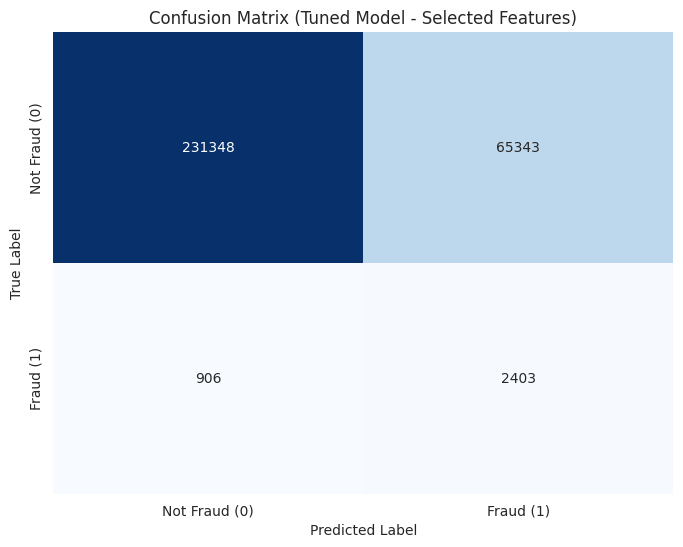

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the best parameters from the Optuna study
best_params = study.best_params

# Initialize a new LightGBM Classifier with the best parameters
lgbm_tuned = lgb.LGBMClassifier(**best_params, objective='binary', metric='auc', is_unbalance=True, random_state=42, n_jobs=-1)

print("Training LightGBM model with best hyperparameters on selected features...")
lgbm_tuned.fit(X_train_selected_df, y_train)
print("LightGBM model training with best hyperparameters complete.")

# Predict probabilities and class labels on the test set
y_pred_proba_tuned = lgbm_tuned.predict_proba(X_test_selected_df)[:, 1]
y_pred_tuned = lgbm_tuned.predict(X_test_selected_df)

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

# --- Original model metrics (from previous execution) ---
accuracy_original = 0.8925
precision_original = 0.0676
recall_original = 0.6836
f1_original = 0.1230
auc_original = 0.8860

# --- Selected features model (before tuning) metrics ---
accuracy_selected = accuracy_selected # from previous cell output
precision_selected = precision_selected # from previous cell output
recall_selected = recall_selected # from previous cell output
f1_selected = f1_selected # from previous cell output
auc_selected = auc_selected # from previous cell output

# Create a DataFrame for comparison
metrics_data_final = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Original Model': [accuracy_original, precision_original, recall_original, f1_original, auc_original],
    'Selected Features Model (untuned)': [accuracy_selected, precision_selected, recall_selected, f1_selected, auc_selected],
    'Selected Features Model (tuned)': [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned, auc_tuned]
}
comparison_df_final = pd.DataFrame(metrics_data_final)

print("\n--- Final Model Performance Comparison ---")
display(comparison_df_final)

# Confusion Matrix for the tuned model
print("\nConfusion Matrix for Tuned Model (Selected Features):")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Model - Selected Features)')
plt.show()